# Lezione 5.1: Fondamenti di Scikit-Learn con Bike Sharing

In questo notebook esploreremo i concetti fondamentali di **Scikit-Learn** applicandoli al nostro caso di studio reale: il dataset **European Bike Sharing**.

## Obiettivi
1.  Caricare e preparare i dati (Preprocessing).
2.  Introdurre delle nuove feature
3.  Capire la struttura `X` (Features) e `y` (Target).
4.  Utilizzare l'API Estimator per addestrare un modello di Regressione Lineare.
5.  Valutare il modello con metriche di base (MAE, RMSE).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione grafici
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Caricamento dei Dati

Utilizziamo il CSV del notebook precedente. data-1770028573715

In [2]:
# Caricamento dati da CSV (estratti dal DWH)
df = pd.read_csv("03.02_bikesharing_sintetico.csv")

# Parsing data
df['data_completa'] = pd.to_datetime(df['data_completa'])

df.head()


,data_completa,mese,giorno_settimana,is_weekend,temp_c,pioggia_mm,evento,total_rentals,settimana_anno
0,2025-01-01,1,2,0,8.0,0.0,0,122,1
1,2025-01-02,1,3,0,4.7,0.0,0,94,1
2,2025-01-03,1,4,0,9.2,0.0,0,104,1
3,2025-01-04,1,5,1,9.7,0.0,0,116,1
4,2025-01-05,1,6,1,2.5,0.0,0,131,1


Ordiniamo per tempo

In [3]:
# Ordinamento temporale
df = df.sort_values("data_completa").reset_index(drop=True)


Lag -diciamo al modello cosa è successo ieri

In [4]:
# Feature: valore del giorno precedente
df['lag_1'] = df['total_rentals'].shift(1)


Media mobile (trend)

In [5]:
# Feature: media mobile ultimi 7 giorni
df['rolling_7'] = df['total_rentals'].rolling(window=7).mean()


Pulizia delle righe perchè alcune righe avranno valori nulli

In [6]:
# Rimuoviamo le righe iniziali con valori mancanti
df = df.dropna().reset_index(drop=True)


stagionalità ciclica, rappresentazione del mese usando seno e coseno

In [7]:
# Trasformazione ciclica del mese
df['mese_sin'] = np.sin(2 * np.pi * df['mese'] / 12)
df['mese_cos'] = np.cos(2 * np.pi * df['mese'] / 12)


ridefiniamo le feature

In [8]:
features = [
    'giorno_settimana',
    'is_weekend',
    'lag_1',
    'rolling_7',
    'mese_sin',
    'mese_cos'
]

X = df[features]
y = df['total_rentals']

print(f"Shape di X: {X.shape}")
print(f"Shape di y: {y.shape}")

Shape di X: (359, 6)
Shape di y: (359,)


split temporale non random

In [9]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


allenamento

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


print("Intercetta:", model.intercept_)
print("Coefficienti:", dict(zip(features, model.coef_)))


Intercetta: 8.94416244430954
Coefficienti: {'giorno_settimana': np.float64(1.3739999862012673), 'is_weekend': np.float64(-4.791482858672945), 'lag_1': np.float64(0.5201552910241931), 'rolling_7': np.float64(0.3811521929470115), 'mese_sin': np.float64(-1.8092465359299004), 'mese_cos': np.float64(-7.280843662072775)}


valutazione

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE (Errore Medio Assoluto): {mae:.2f}")
print(f"RMSE (Radice Errore Quadratico Medio): {rmse:.2f}")


MAE (Errore Medio Assoluto): 14.48
RMSE (Radice Errore Quadratico Medio): 18.77


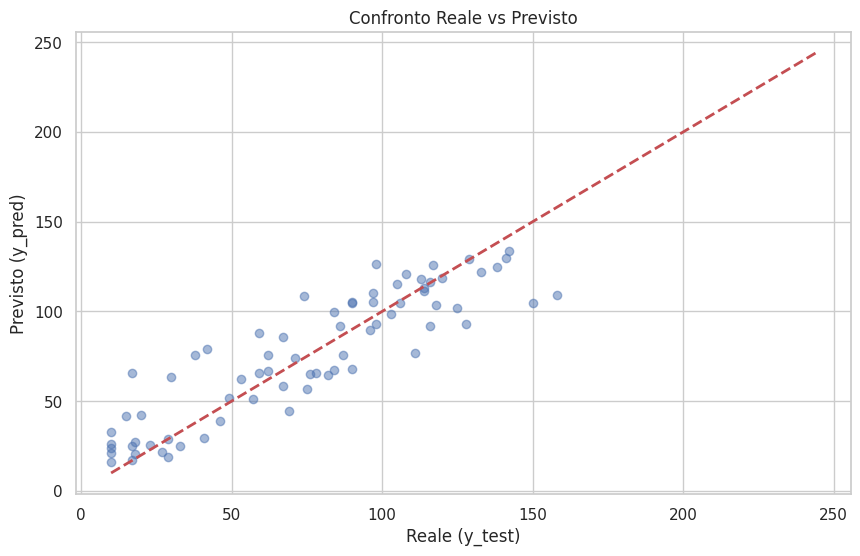

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Linea ideale
plt.xlabel('Reale (y_test)')
plt.ylabel('Previsto (y_pred)')
plt.title('Confronto Reale vs Previsto')
plt.show()